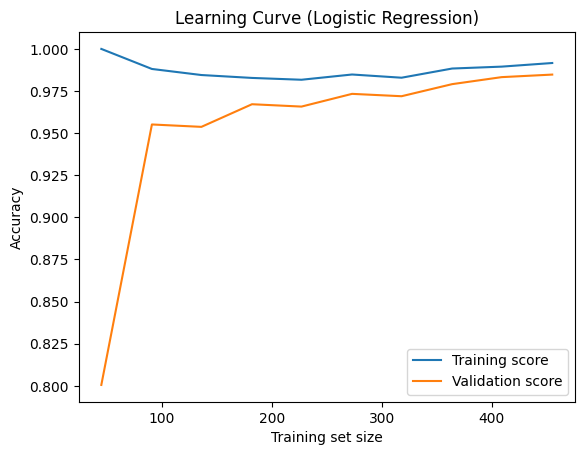

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X, y = load_breast_cancer(return_X_y=True)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000))
])

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="f1",
    n_jobs=-1
    
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Learning Curve (Logistic Regression)")
plt.show()
